In [1]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1. Base Theme & Context
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 2. Fine-grained RC Parameters
plt.rcParams.update({
    # Fonts & Sizes
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,      # Suptitle size
    'axes.titlesize': 16,        # Ax title size (Standardized to 16)
    'axes.labelsize': 12,        # Ax label size

    # Weights (Bold globally)
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    # Structural Defaults
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):
    """
    Applies structural formatting only.
    Styling (size/bold) is now handled automatically by rcParams.
    """
    # Just set the text. The Global Config handles size/bolding.
    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Grid Logic (Structural)
    # Note: We must explicitly turn OFF the opposing grid
    # because seaborn defaults might keep it on.
    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [5]:
df.isnull().values.any()

np.False_

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [8]:
# GROUP 1: DEMOGRAPHIC & ANTHROPOMETRIC BASELINES
# Source: Electronic Health Records (EHR) and Standard Physical Measurement.
df_demographic = df[[
    'Age',                    # Range: 20-96 years
    'Gender',                 # Binary: 0=Male, 1=Female
    'Height',                 # Measured barefoot (cm)
    'Weight',                 # Measured with thin clothing (kg)
    'Body Mass Index (BMI)'   # Calculation: weight/height² (kg/m²)
]].copy()

In [9]:
# GROUP 2A: COMORBIDITY SCORE (ORDINAL)
# Source: Medical History Review.
# [cite_start]DATASET ERROR: The paper describes 'Comorbidity' as a binary variable[cite: 68], but the dataset contains ordinal values (0-3), likely indicating a severity score or count.
df_comorbidity_score = df[[
    'Comorbidity'             # Ordinal Variable (Severity/Count)
]].copy()

In [10]:
# GROUP 2B: CLINICAL CONDITIONS (BINARY)
# Source: Medical History Flags.
# DATASET ERROR: The CSV header 'Coronary Artery Disease (CAD)' contradicts the paper, which lists 'Hypertension' as the feature[cite: 69].
df_clinical_conditions = df[[
    'Coronary Artery Disease (CAD)', # Dataset lists CAD; Paper lists Hypertension
    'Hypothyroidism',                # Diagnosed Thyroid deficiency
    'Hyperlipidemia',                # High lipid levels
    'Diabetes Mellitus (DM)'         # Diabetic status
]].copy()

In [11]:
# GROUP 2C: HEPATIC FAT ACCUMULATION (IMAGING)
# Source: Ultrasonography.
# Note: Direct imaging diagnosis, distinct from BIA predictions.
df_hepatic_fat = df[[
    'Hepatic Fat Accumulation (HFA)' # Fatty liver severity (Grades 0-3)
]].copy()

In [12]:
# GROUP 3: BIOELECTRICAL IMPEDANCE ANALYSIS (BIA)
# Source: Tanita MC780 Body Composition Analyzer.
# Method: Non-invasive electrical resistance measurement of tissues.
df_bioimpedance = df[[
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

In [13]:
# GROUP 4: LABORATORY & METABOLIC MARKERS
# Source: Clinical Blood Panels.
# Method: Standard biochemical analysis.
df_laboratory = df[[
    'Glucose',                        # Blood sugar (mg/dL)
    'Total Cholesterol (TC)',         # Lipid profile (mg/dL)
    'Low Density Lipoprotein (LDL)',  # "Bad" cholesterol (mg/dL)
    'High Density Lipoprotein (HDL)', # "Good" cholesterol (mg/dL)
    'Triglyceride',                   # Fat in blood (mg/dL)
    'Aspartat Aminotransferaz (AST)', # Liver enzyme (U/L)
    'Alanin Aminotransferaz (ALT)',   # Liver enzyme (U/L)
    'Alkaline Phosphatase (ALP)',     # Liver enzyme (U/L)
    'Creatinine',                     # Kidney function (mg/dL)
    'Glomerular Filtration Rate (GFR)', # Filtration speed (ml/sec or mL/min)
    'C-Reactive Protein (CRP)',       # Inflammation marker (mg/L)
    'Hemoglobin (HGB)',               # Oxygen carrying protein (g/dL)
    'Vitamin D'                       # Nutrient concentration (ng/mL)
]].copy()

In [14]:
# GROUP 5: TARGET VARIABLE
# Source: Clinical Diagnosis (Gold Standard).
df_gallstone = df[[
    'Gallstone Status'        # Binary Target: 0=Healthy, 1=Patient
]].copy()

In [15]:
# 1. Dictionary of all Feature Groups (Excluding Target for now)
data_groups = {
    "1. Demographic": df_demographic,
    "2a. Comorb. (Score)": df_comorbidity_score,
    "2b. Chronic Cond.": df_clinical_conditions,
    "2c. Hepatic Fat": df_hepatic_fat,
    "3. Bioimpedance": df_bioimpedance,
    "4. Laboratory": df_laboratory
}

# 2. Print Dimensions
print(f"{'GROUP SUBSET':<30} | {'SHAPE (Rows, Cols)'}")
print("-" * 55)

selected_feature_cols = []
total_feature_count = 0

for name, data in data_groups.items():
    print(f"{name:<30} | {data.shape}")
    total_feature_count += data.shape[1]
    selected_feature_cols.extend(data.columns.tolist())

print("-" * 55)

# 3. Dynamic Validation Logic
# Formula: Total Original Columns = (Selected Features) + (Target Columns)
original_total_cols = df.shape[1]
target_col_count = df_gallstone.shape[1]
expected_feature_count = original_total_cols - target_col_count

print(f"Total Selected Features:      {total_feature_count}")
print(f"Target Column Count:          {target_col_count} (df_gallstone)")
print(f"Original DataFrame Columns:   {original_total_cols}")
print("-" * 55)

# 4. Strict Set Identity Check
all_original_cols = set(df.columns)
all_accounted_cols = set(selected_feature_cols).union(set(df_gallstone.columns))

if total_feature_count == expected_feature_count and all_accounted_cols == all_original_cols:
    print("✅ INTEGRITY SUCCESS: All columns preserved and accounted for.")
    print("   No columns were dropped, duplicated, or missed.")
else:
    missing = all_original_cols - all_accounted_cols
    print(f"❌ INTEGRITY FAIL: Mismatch detected.")
    if missing:
        print(f"🔍 MISSING COLUMNS: {missing}")
    else:
        print(f"🔍 DUPLICATION DETECTED (Check group definitions).")

GROUP SUBSET                   | SHAPE (Rows, Cols)
-------------------------------------------------------
1. Demographic                 | (319, 5)
2a. Comorb. (Score)            | (319, 1)
2b. Chronic Cond.              | (319, 4)
2c. Hepatic Fat                | (319, 1)
3. Bioimpedance                | (319, 14)
4. Laboratory                  | (319, 13)
-------------------------------------------------------
Total Selected Features:      38
Target Column Count:          1 (df_gallstone)
Original DataFrame Columns:   39
-------------------------------------------------------
✅ INTEGRITY SUCCESS: All columns preserved and accounted for.
   No columns were dropped, duplicated, or missed.


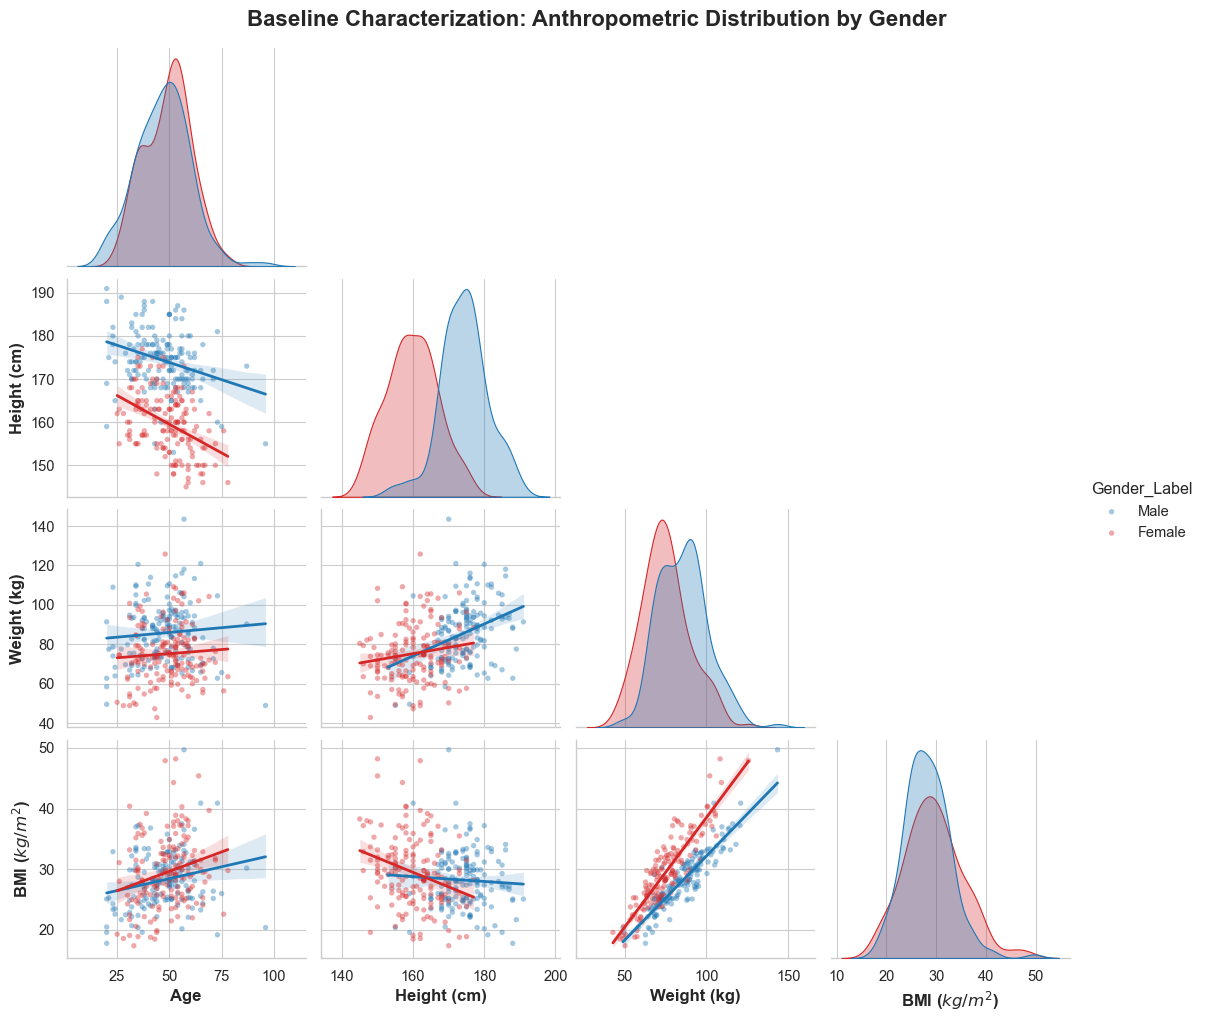

In [16]:
# 1. Prepare Data
df_viz = df_demographic.rename(columns={
    'Body Mass Index (BMI)': 'BMI ($kg/m^2$)',
    'Height': 'Height (cm)',
    'Weight': 'Weight (kg)'
})
# Ensure Gender_Label exists
df_viz['Gender_Label'] = df_viz['Gender'].map({0: 'Male', 1: 'Female'})

# 2. Define Palette (Blue/Red)
# 'tab:blue' (Standard Blue) vs 'tab:red' (Standard Red)
comparison_palette = {'Male': 'tab:blue', 'Female': 'tab:red'}

# 3. Generate Plot
g = sns.pairplot(
    df_viz,
    hue='Gender_Label',
    vars=['Age', 'Height (cm)', 'Weight (kg)', 'BMI ($kg/m^2$)'],
    kind='reg',
    diag_kind='kde',
    palette=comparison_palette,  # <--- APPLIED: Blue vs Red

    # Visual Tweaks
    plot_kws={
        'scatter_kws': {'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
        'line_kws': {'linewidth': 2}
    },
    diag_kws={'fill': True, 'alpha': 0.3},
    height=2.5,
    aspect=1.1,
    corner=True
)

# 4. Formal Title
g.fig.suptitle(
    'Baseline Characterization: Anthropometric Distribution by Gender',
    y=1.02,
    fontsize=16,
    fontweight='bold'
)

plt.show()

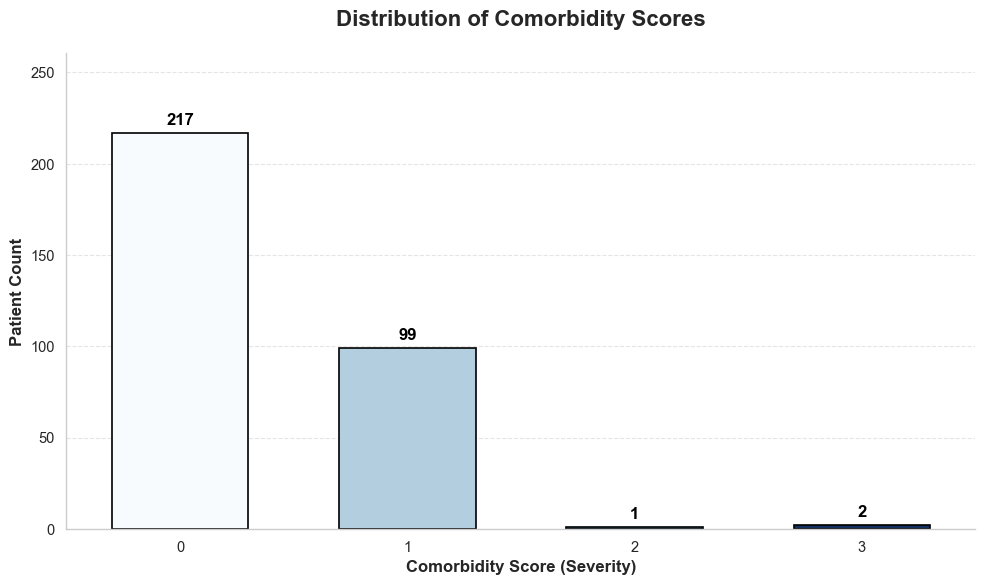

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# A. Data Preparation
counts = df_comorbidity_score['Comorbidity'].value_counts()
max_score = int(df_comorbidity_score['Comorbidity'].max())
plot_data = counts.reindex(range(max_score + 1), fill_value=0)

# B. Plot Generation (Severity Gradient)
# Hue is mapped to X to enable the palette.
sns.barplot(
    x=plot_data.index.astype(int),
    y=plot_data.values,
    hue=plot_data.index.astype(int), # Enables gradient
    palette='Blues',                 # <--- Applied: Severity Gradient
    ax=ax,
    edgecolor='black',
    width=0.6,
    linewidth=1.2,
    dodge=False,                     # Keeps bars centered
    legend=False                     # Hides redundant legend
)

# C. Apply Standard Formatting
format_plot(
    ax=ax,
    title='Distribution of Comorbidity Scores',
    xlabel='Comorbidity Score (Severity)',
    ylabel='Patient Count'
)

# D. Visual Tweaks
# The "Clean Look" (Removes box borders)
sns.despine(ax=ax)

# Headroom
ax.set_ylim(0, plot_data.max() * 1.2)

# Uniform Labels
for container in ax.containers:
    # Black text ensures contrast even on the darker 'Grade 3' bar
    ax.bar_label(container, padding=4, color='black', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

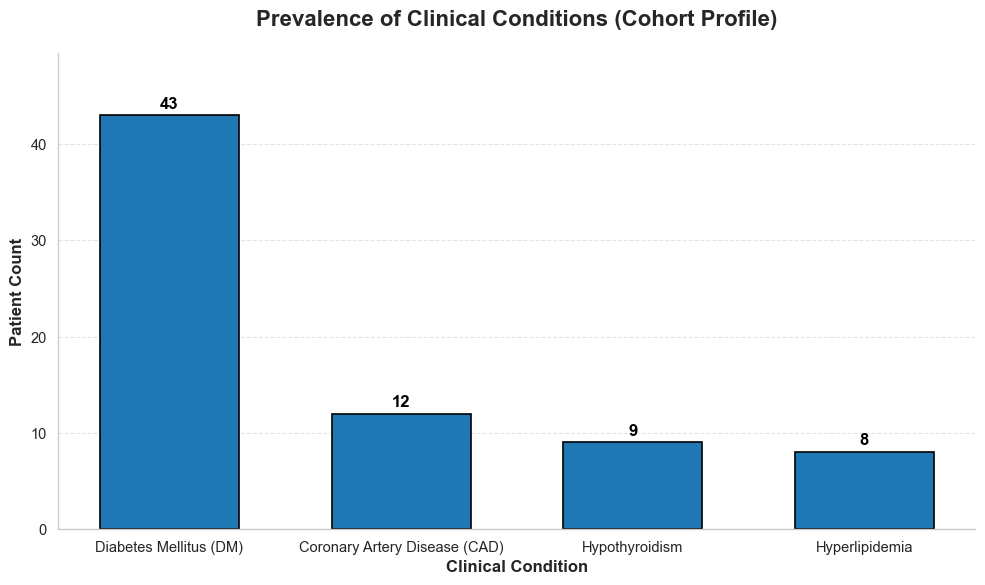

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# A. Data Processing
# Using df_clinical_conditions (where CAD was renamed to Hypertension)
prevalence = df_clinical_conditions.sum().sort_values(ascending=False)

# B. Plot Generation
# Color: 'tab:blue' (Flat) implies categorical equality (not severity).
bars = ax.bar(
    prevalence.index,
    prevalence.values,
    color='tab:blue',        # Applied: Neutral Academic Standard
    edgecolor='black',
    width=0.6,
    linewidth=1.2
)

# C. Apply Standard Formatting
format_plot(
    ax=ax,
    title='Prevalence of Clinical Conditions (Cohort Profile)',
    xlabel='Clinical Condition',
    ylabel='Patient Count'
)

# D. Visual Tweaks
# The "Clean Look" (Removes box borders)
sns.despine(ax=ax)

# Headroom
ax.set_ylim(0, prevalence.max() * 1.15)

# Uniform Labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontweight='bold',
        color='black',
        fontsize=12
    )

plt.tight_layout()
plt.show()

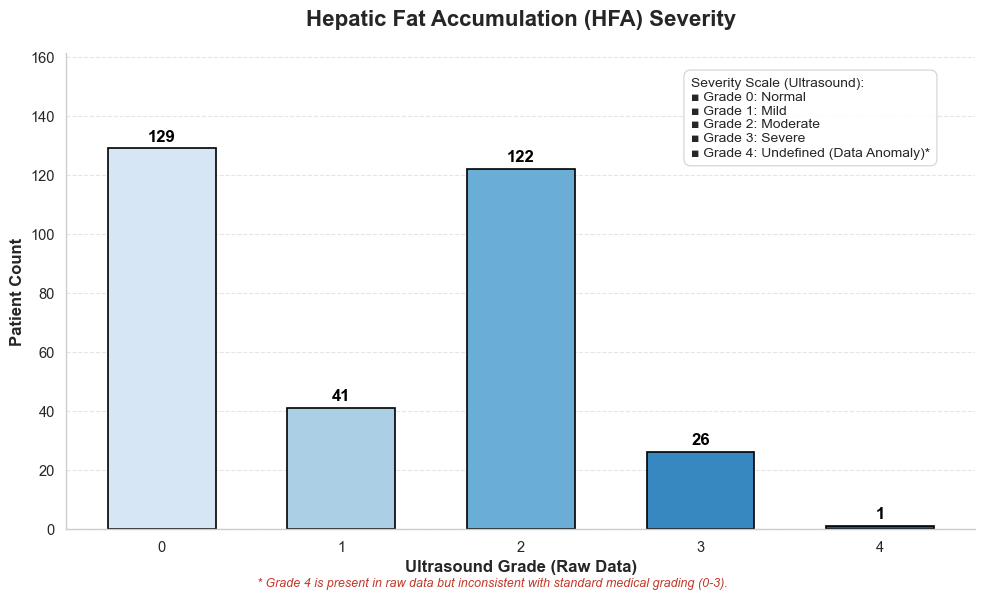

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Prepare Data
plot_data = df_hepatic_fat['Hepatic Fat Accumulation (HFA)'].value_counts().sort_index()

# 2. Plot Generation (Severity Gradient - Blues)
blue_gradient = sns.color_palette("Blues", n_colors=len(plot_data))

bars = ax.bar(
    plot_data.index.astype(str),
    plot_data.values,
    color=blue_gradient,
    edgecolor='black',
    width=0.6,
    linewidth=1.2
)

# 3. Apply Standard Formatting
format_plot(
    ax=ax,
    title='Hepatic Fat Accumulation (HFA) Severity',
    xlabel='Ultrasound Grade (Raw Data)',
    ylabel='Patient Count'
)

# 4. Visual Tweaks
sns.despine(ax=ax)
ax.set_ylim(0, plot_data.max() * 1.25)

# Uniform Labels
ax.bar_label(bars, padding=3, fontweight='bold', color='black', fontsize=12)

# 5. Contextual Annotation (FIXED INNER ALIGNMENT)
legend_text = (
    "Severity Scale (Ultrasound):\n"
    "■ Grade 0: Normal\n"
    "■ Grade 1: Mild\n"
    "■ Grade 2: Moderate\n"
    "■ Grade 3: Severe\n"
    "■ Grade 4: Undefined (Data Anomaly)*"
)

ax.text(
    0.95, 0.95, legend_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right', # Anchor the box to the right
    multialignment='left',       # <--- FIX: Text INSIDE the box aligns left
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor='#CCCCCC')
)

# Footnote for the Anomaly (Red)
if 4 in plot_data.index:
    plt.figtext(
        0.5, 0.01,
        "* Grade 4 is present in raw data but inconsistent with standard medical grading (0-3).",
        ha="center", fontsize=9, color="#C0392B", style='italic'
    )

plt.tight_layout()
plt.show()

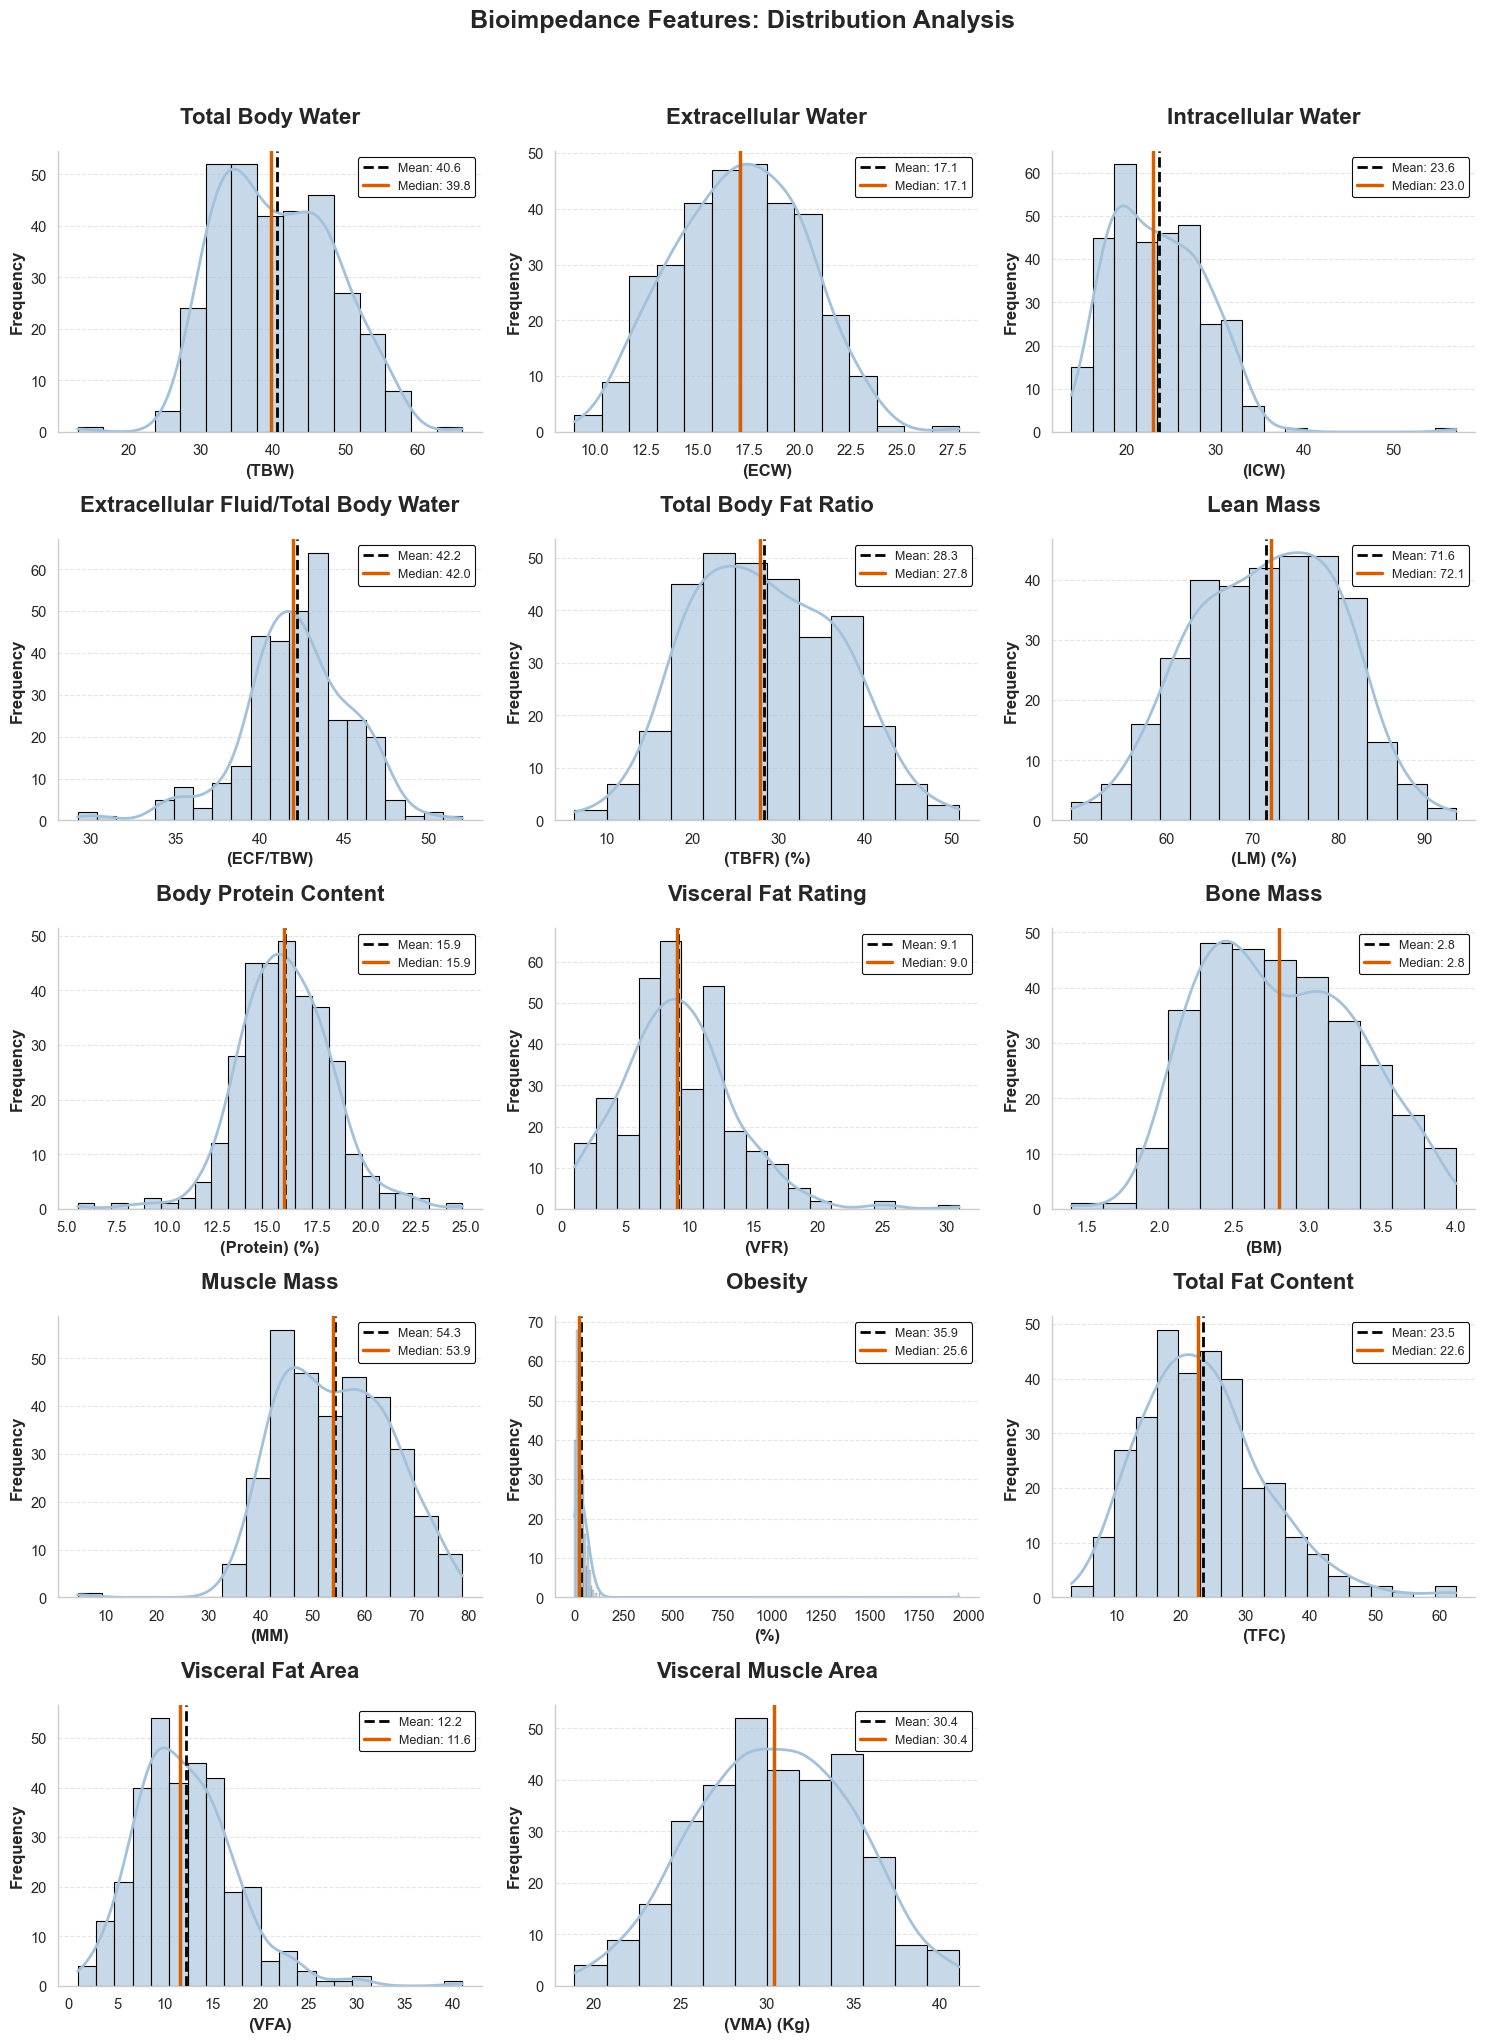

In [20]:
# 1. Configuration
features_to_plot = df_bioimpedance.columns
cols = 3
n_features = len(features_to_plot)
rows = math.ceil(n_features / cols)

# 2. Setup Canvas
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
fig.suptitle(
    'Bioimpedance Features: Distribution Analysis',
    fontsize=18, y=1.02, fontweight='bold'
)

axes_flat = axes.flatten()

# 3. Plotting Loop
for i, col_name in enumerate(features_to_plot):
    ax = axes_flat[i]

    # Calculate Statistics
    mean_val = df_bioimpedance[col_name].mean()
    median_val = df_bioimpedance[col_name].median()

    # Unit Extraction
    if '(' in col_name:
        clean_title = col_name.split('(')[0].strip()
        unit_text = col_name[col_name.find('('):]
    else:
        clean_title = col_name
        unit_text = ""

    # [Correction 1] The Plot (Lighter Bars)
    sns.histplot(
        data=df_bioimpedance,
        x=col_name,
        kde=True,
        ax=ax,
        color='#A3C1DA',  # <--- FIX: "Light Steel Blue" (Passive Background)
        edgecolor='black',
        alpha=0.6,        # Semi-transparent to let grid/lines breathe
        line_kws={'linewidth': 2, 'color': '#003366'} # Dark Blue KDE Line (Shape Definition)
    )

    # [Correction 2] High-Contrast Lines (Colorblind Safe)
    # Mean: BLACK (Dashed)
    ax.axvline(
        mean_val,
        color='black',
        linestyle='--',
        linewidth=2.0,
        label=f'Mean: {mean_val:.1f}',
        zorder=5 # Forces line ON TOP
    )

    # Median: ORANGE (Solid/Dotted) - Vermilion
    ax.axvline(
        median_val,
        color='#D55E00',
        linestyle='-',  # Solid line is often easier to see than dots against light bars
        linewidth=2.5,
        label=f'Median: {median_val:.1f}',
        zorder=5 # Forces line ON TOP
    )

    # [Correction 3] Clean Layout
    format_plot(
        ax,
        clean_title,
        unit_text,
        'Frequency'
    )
    sns.despine(ax=ax)

    # Legend
    ax.legend(fontsize=9, loc='upper right', frameon=True, framealpha=0.95, edgecolor='black')

# 4. Cleanup
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

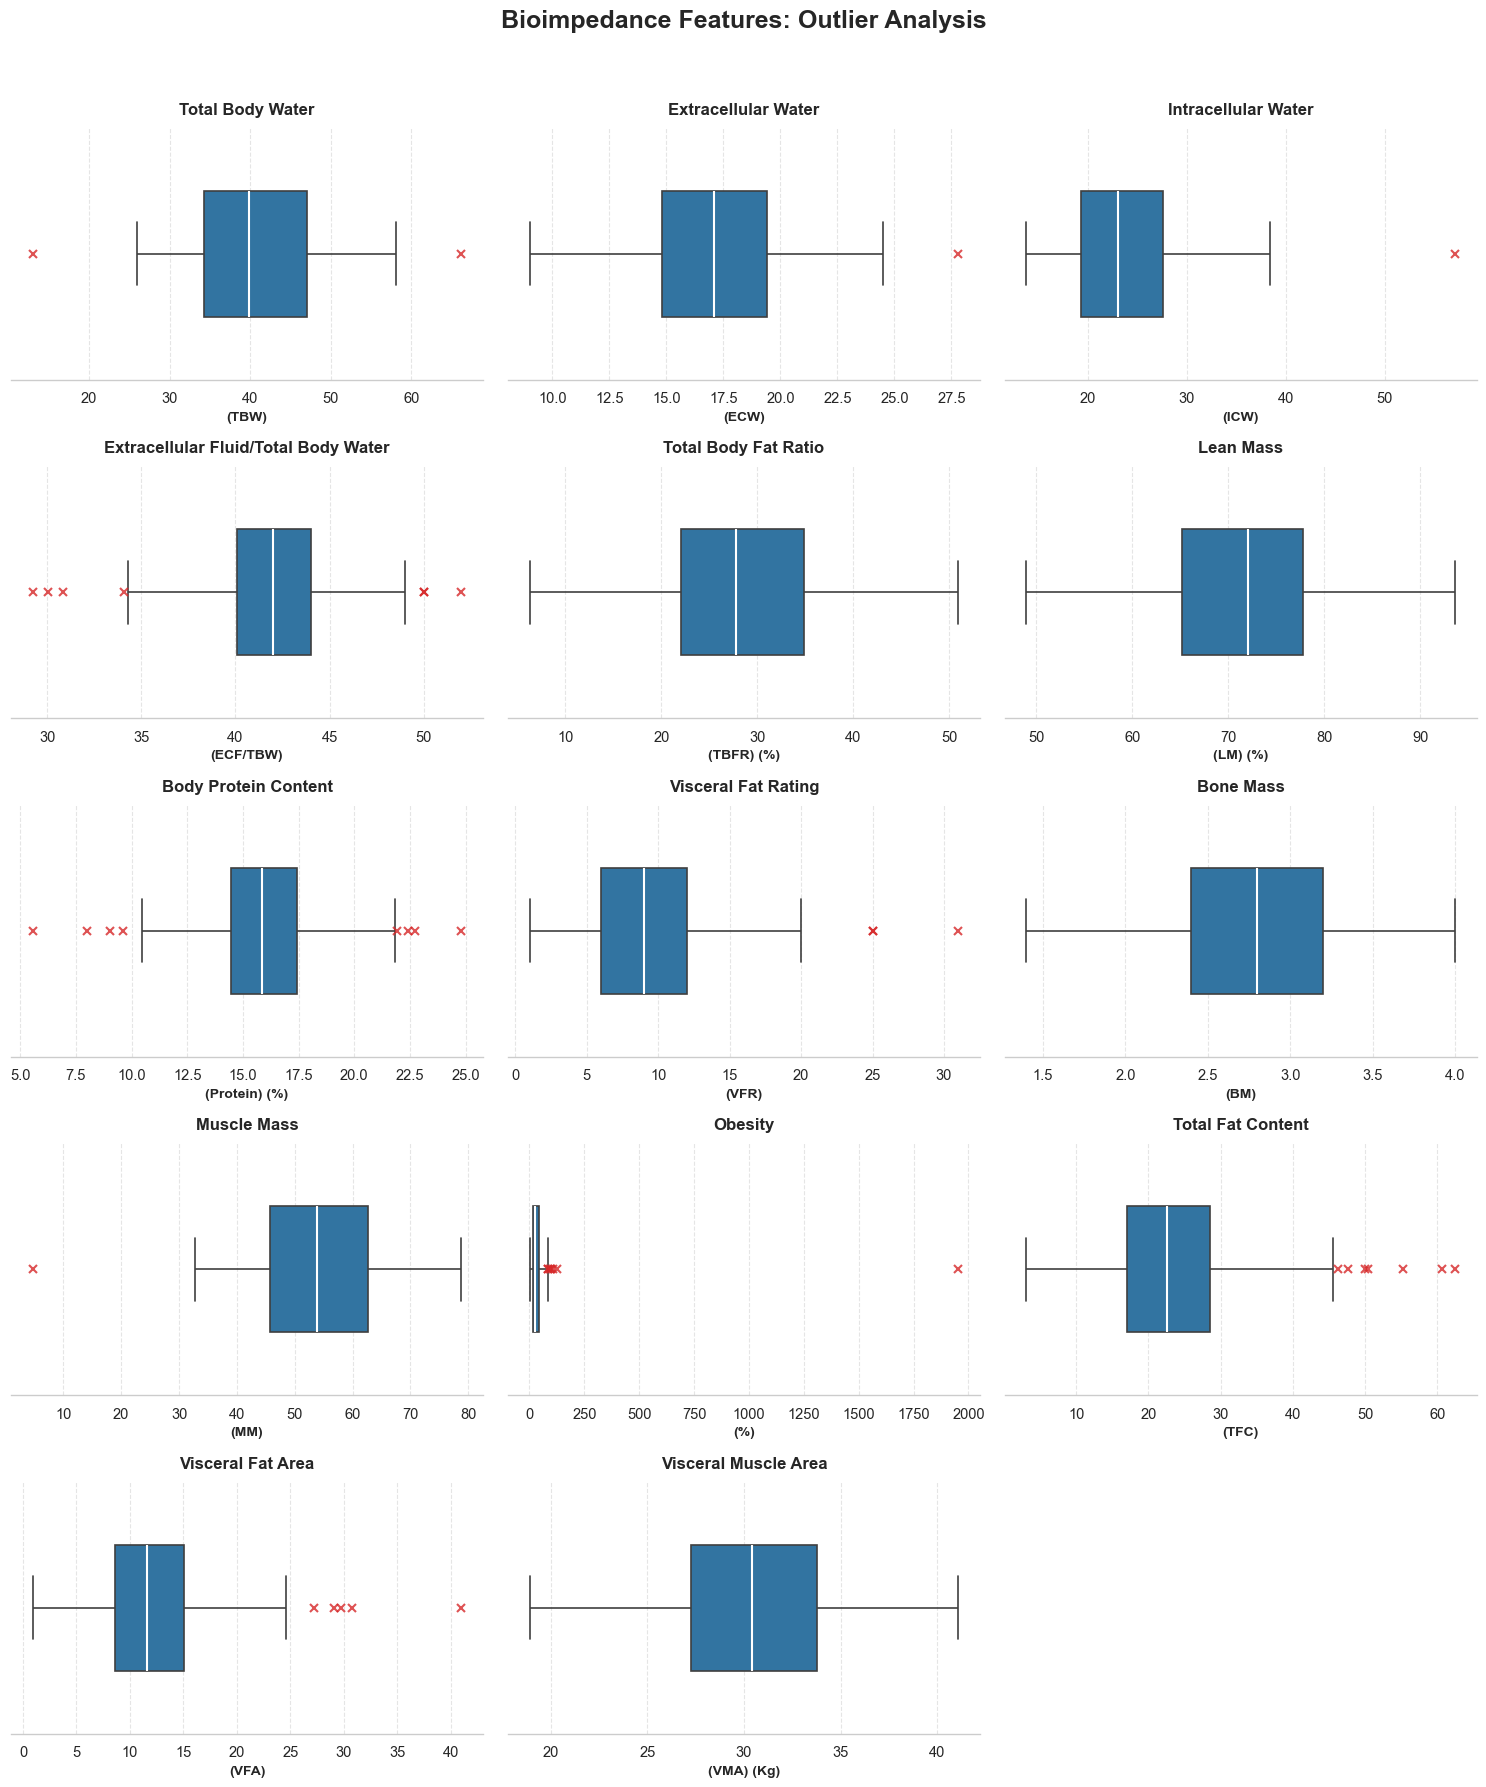

In [21]:
# 1. Configuration
features_to_plot = df_bioimpedance.columns
cols = 3
n_features = len(features_to_plot)
rows = math.ceil(n_features / cols)

# 2. Setup Canvas
fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
fig.suptitle(
    'Bioimpedance Features: Outlier Analysis',
    fontsize=18, y=1.02, fontweight='bold'
)

axes_flat = axes.flatten()

# 3. Plotting Loop
for i, col_name in enumerate(features_to_plot):
    ax = axes_flat[i]

    # Unit Extraction
    if '(' in col_name:
        clean_title = col_name.split('(')[0].strip()
        unit_text = col_name[col_name.find('('):]
    else:
        clean_title = col_name
        unit_text = ""

    # Plot: Horizontal Boxplot
    sns.boxplot(
        data=df_bioimpedance,
        x=col_name,
        ax=ax,
        color='tab:blue',  # <--- Main Data: Standard Blue
        width=0.5,
        linewidth=1.2,

        # Outlier Properties (The "Red" Component)
        flierprops={
            "marker": "x",
            "markeredgecolor": "tab:red",  # <--- Outliers: Standard Red
            "markersize": 6,
            "alpha": 0.8,
            "markeredgewidth": 1.5
        },

        # Median Line (White for contrast against dark blue box)
        medianprops={"color": "white", "linewidth": 1.5}
    )

    # Apply Standard Formatting
    ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(unit_text, fontsize=10, fontweight='bold')
    ax.set_ylabel('', fontsize=10)

    # Visual Cleanliness
    sns.despine(ax=ax, left=True)
    ax.set_yticks([])
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Cleanup
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

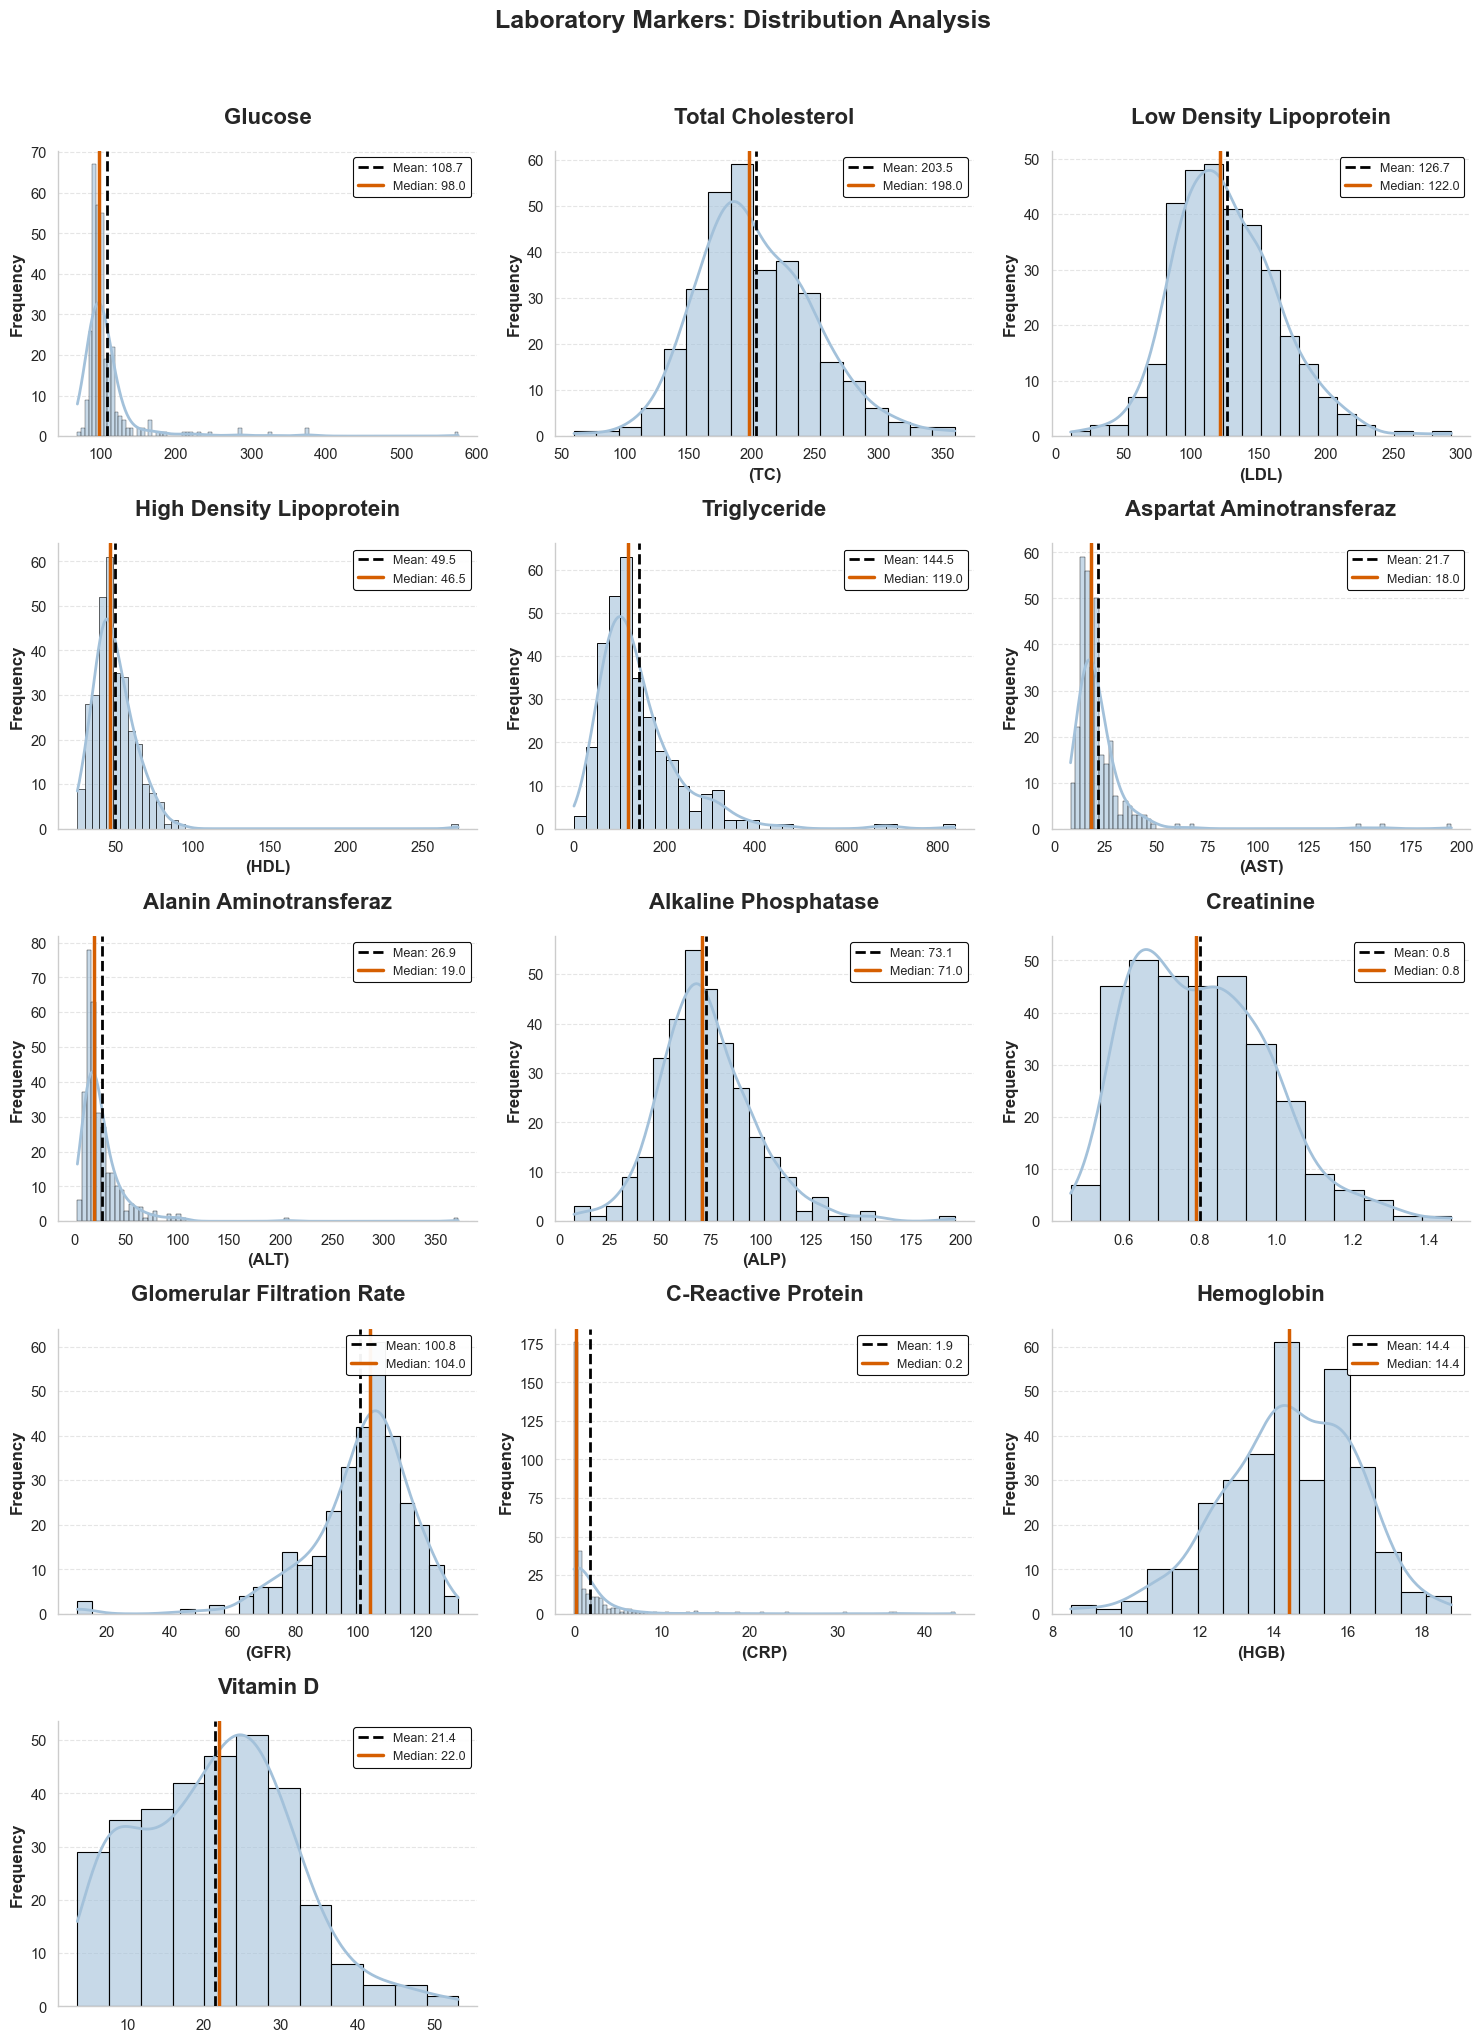

In [22]:
# 1. Configuration
features_to_plot = df_laboratory.columns
cols = 3
n_features = len(features_to_plot)
rows = math.ceil(n_features / cols)

# 2. Setup Canvas
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
fig.suptitle(
    'Laboratory Markers: Distribution Analysis',
    fontsize=18, y=1.02, fontweight='bold'
)

axes_flat = axes.flatten()

# 3. Plotting Loop
for i, col_name in enumerate(features_to_plot):
    ax = axes_flat[i]

    # Calculate Statistics
    mean_val = df_laboratory[col_name].mean()
    median_val = df_laboratory[col_name].median()

    # Unit Extraction
    if '(' in col_name:
        clean_title = col_name.split('(')[0].strip()
        unit_text = col_name[col_name.find('('):]
    else:
        clean_title = col_name
        unit_text = ""

    # [Logic 1] The Plot (Light Steel Blue Background)
    sns.histplot(
        data=df_laboratory,
        x=col_name,
        kde=True,
        ax=ax,
        color='#A3C1DA',  # <--- UNIFIED THEME (Matches Bioimpedance)
        edgecolor='black',
        alpha=0.6,
        line_kws={'linewidth': 2, 'color': '#003366'} # Dark Blue KDE
    )

    # [Logic 2] High-Contrast Lines (The Stars)
    # Mean: BLACK (Dashed)
    ax.axvline(
        mean_val,
        color='black',
        linestyle='--',
        linewidth=2.0,
        label=f'Mean: {mean_val:.1f}',
        zorder=5
    )

    # Median: ORANGE (Solid)
    ax.axvline(
        median_val,
        color='#D55E00',
        linestyle='-',
        linewidth=2.5,
        label=f'Median: {median_val:.1f}',
        zorder=5
    )

    # [Logic 3] Clean Layout & Formatting
    format_plot(
        ax,
        clean_title,
        unit_text,
        'Frequency'
    )
    sns.despine(ax=ax)

    # Legend
    ax.legend(fontsize=9, loc='upper right', frameon=True, framealpha=0.95, edgecolor='black')

# 4. Cleanup
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

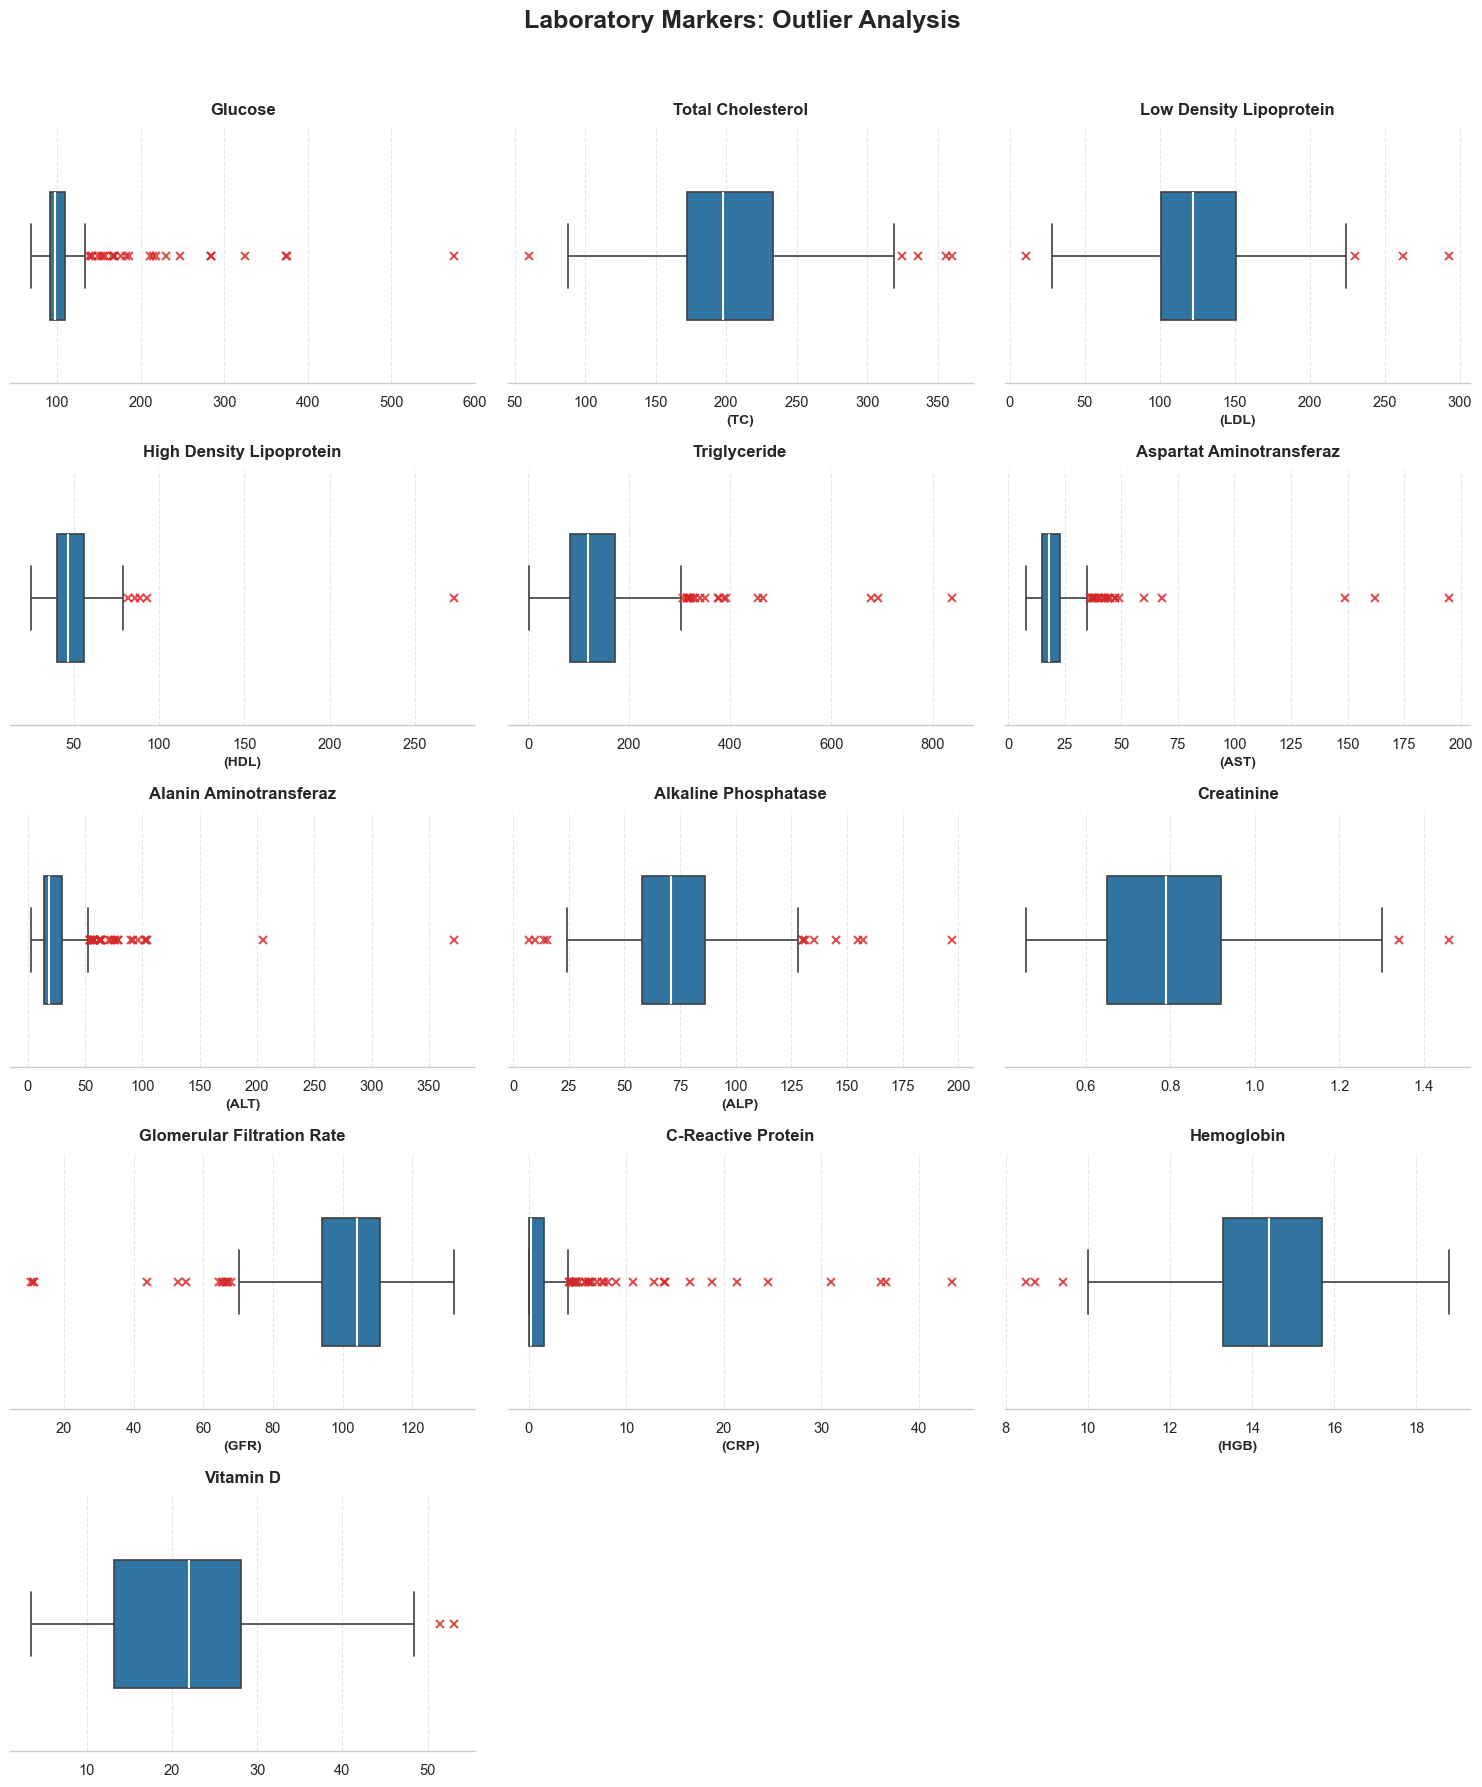

In [23]:
# 1. Configuration
features_to_plot = df_laboratory.columns
cols = 3
n_features = len(features_to_plot)
rows = math.ceil(n_features / cols)

# 2. Setup Canvas
fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows)) # Matches Fig 6 height
fig.suptitle(
    'Laboratory Markers: Outlier Analysis',
    fontsize=18, fontweight='bold', y=1.02
)

axes_flat = axes.flatten()

# 3. Plotting Loop
for i, col_name in enumerate(features_to_plot):
    ax = axes_flat[i]

    # Unit Extraction
    if '(' in col_name:
        clean_title = col_name.split('(')[0].strip()
        unit_text = col_name[col_name.find('('):]
    else:
        clean_title = col_name
        unit_text = ""

    # [Standardization] The Plot (Blue Box / Red Outliers)
    sns.boxplot(
        data=df_laboratory,
        x=col_name,
        ax=ax,
        color='tab:blue',   # <--- FIX: Matches Report Theme
        width=0.5,
        linewidth=1.2,

        # Outlier Props (The "Red" Warning)
        flierprops={
            "marker": "x",
            "markeredgecolor": "tab:red",  # <--- FIX: High Contrast Outliers
            "markersize": 6,
            "alpha": 0.8,
            "markeredgewidth": 1.5
        },

        # Median Line (White for contrast against Blue)
        medianprops={"color": "white", "linewidth": 1.5}
    )

    # [Standardization] Apply Labels
    ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(unit_text, fontsize=10, fontweight='bold')
    ax.set_ylabel('', fontsize=10)

    # [Standardization] Clean "Number Line" Look
    sns.despine(ax=ax, left=True) # Remove left spine
    ax.set_yticks([])             # Remove Y ticks
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Cleanup
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()